In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_excel("India_Earthquake_Cleaned.xlsx")

print("\n===== INITIAL DATA HEAD =====")
print(df.head())

print("\n===== INITIAL SHAPE =====")
print(df.shape)

print("\n===== INITIAL NULL VALUES =====")
print(df.isna().sum())

print("\n===== INITIAL DATA TYPES =====")
print(df.dtypes)

print("\n===== No. of Duplicate Rows BEFORE removing =====")
print(df.duplicated().sum())




===== INITIAL DATA HEAD =====
          Origin Time  Latitude  Longitude  Depth  Magnitude  \
0 2023-04-09 17:47:42      9.00      94.10     30        5.6   
1 2023-04-09 16:01:29      9.19      93.90     10        5.2   
2 2023-04-09 13:16:18      9.30      94.80     15        5.1   
3 2023-03-17 23:49:08     38.49      75.86    102        5.2   
4 2023-03-06 05:07:16      7.77      91.78     45        5.4   

                                            Location  
0  222km N of Campbell Bay, Andaman and Nicobar i...  
1  242km N of Campbell Bay, Andaman and Nicobar i...  
2  273km NNE of Campbell Bay, Andaman and Nicobar...  
3                  438km N of Kargil, Laddakh, India  
4  249km WNW of Campbell Bay, Andaman and Nicobar...  

===== INITIAL SHAPE =====
(2274, 6)

===== INITIAL NULL VALUES =====
Origin Time    0
Latitude       0
Longitude      0
Depth          0
Magnitude      0
Location       0
dtype: int64

===== INITIAL DATA TYPES =====
Origin Time    datetime64[ns]
Latitud

In [ ]:
print("\n===== Shape AFTER removing duplicates =====")
print(df.shape)


num_cols_raw = df.select_dtypes(include=['int64','float64']).columns
cat_cols_raw = df.select_dtypes(include=['object']).columns

df[num_cols_raw] = df[num_cols_raw].fillna(df[num_cols_raw].median())
df[cat_cols_raw] = df[cat_cols_raw].fillna(df[cat_cols_raw].mode().iloc[0])


===== Shape AFTER removing duplicates =====
(2274, 6)


In [ ]:
print("\n===== NULL VALUES After Filling =====")
print(df.isna().sum())

print("\n===== Data (After filling missing values) =====")
print(df.head())


===== NULL VALUES After Filling =====
Origin Time    0
Latitude       0
Longitude      0
Depth          0
Magnitude      0
Location       0
dtype: int64

===== Data (After filling missing values) =====
          Origin Time  Latitude  Longitude  Depth  Magnitude  \
0 2023-04-09 17:47:42      9.00      94.10     30        5.6   
1 2023-04-09 16:01:29      9.19      93.90     10        5.2   
2 2023-04-09 13:16:18      9.30      94.80     15        5.1   
3 2023-03-17 23:49:08     38.49      75.86    102        5.2   
4 2023-03-06 05:07:16      7.77      91.78     45        5.4   

                                            Location  
0  222km N of Campbell Bay, Andaman and Nicobar i...  
1  242km N of Campbell Bay, Andaman and Nicobar i...  
2  273km NNE of Campbell Bay, Andaman and Nicobar...  
3                  438km N of Kargil, Laddakh, India  
4  249km WNW of Campbell Bay, Andaman and Nicobar...  


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

df["Origin Time"] = pd.to_datetime(df["Origin Time"], errors="coerce")

print("\n===== After Converting 'Origin Time' to Datetime =====")
print(df[["Origin Time"]].head())

df["Year"] = df["Origin Time"].dt.year
df["Month"] = df["Origin Time"].dt.month
df["Day"] = df["Origin Time"].dt.day
df["Hour"] = df["Origin Time"].dt.hour
df["Minute"] = df["Origin Time"].dt.minute

print("\n===== After Time Feature Extraction =====")
print(df[["Year","Month","Day","Hour","Minute"]].head())


===== After Converting 'Origin Time' to Datetime =====
          Origin Time
0 2023-04-09 17:47:42
1 2023-04-09 16:01:29
2 2023-04-09 13:16:18
3 2023-03-17 23:49:08
4 2023-03-06 05:07:16

===== After Time Feature Extraction =====
   Year  Month  Day  Hour  Minute
0  2023      4    9    17      47
1  2023      4    9    16       1
2  2023      4    9    13      16
3  2023      3   17    23      49
4  2023      3    6     5       7


In [ ]:
def extract_region(text):
    if pd.isna(text):
        return "Unknown"
    return text.split(",")[-1].strip()

df["Region"] = df["Location"].apply(extract_region)

print("\n===== Unique Regions Extracted =====")
print(df["Region"].unique())

df = df.drop(columns=["Location", "Origin Time"])

print("\n===== Data After Dropping Columns =====")
print(df.head())



===== Unique Regions Extracted =====
['India']

===== Data After Dropping Columns =====
   Latitude  Longitude  Depth  Magnitude  Year  Month  Day  Hour  Minute  \
0      9.00      94.10     30        5.6  2023      4    9    17      47   
1      9.19      93.90     10        5.2  2023      4    9    16       1   
2      9.30      94.80     15        5.1  2023      4    9    13      16   
3     38.49      75.86    102        5.2  2023      3   17    23      49   
4      7.77      91.78     45        5.4  2023      3    6     5       7   

  Region  
0  India  
1  India  
2  India  
3  India  
4  India  


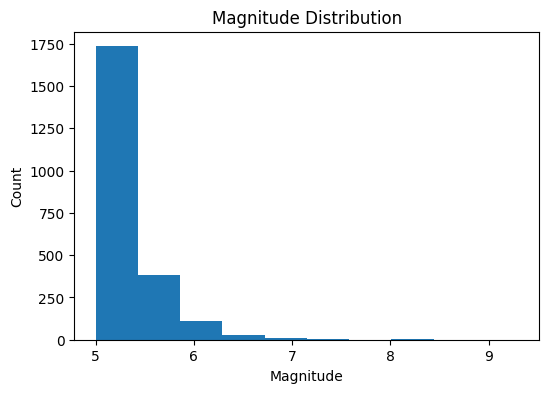

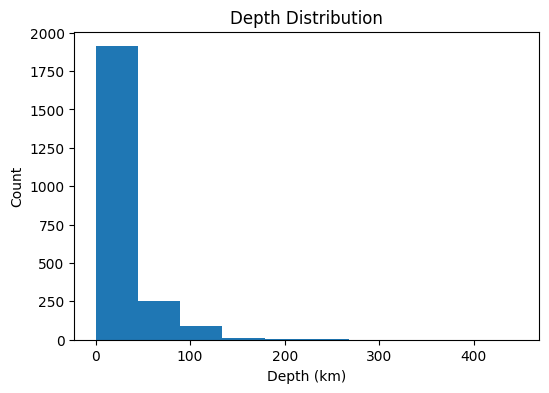

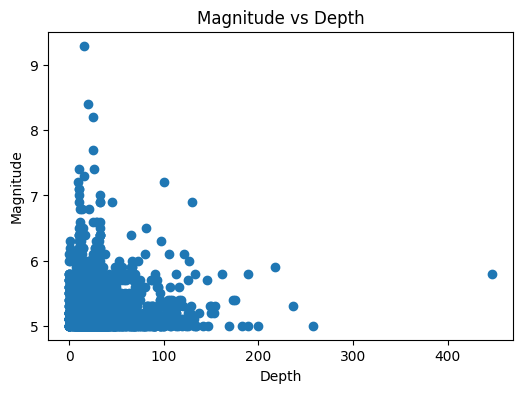

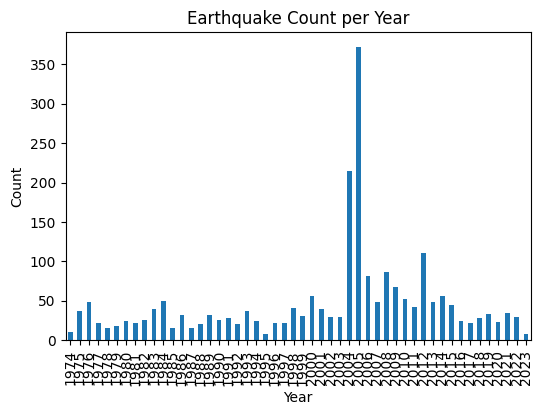

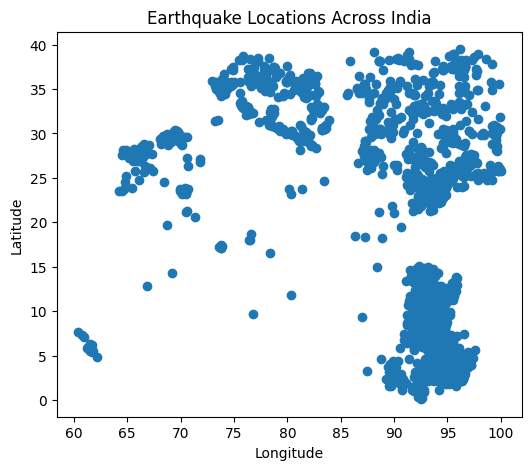

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Magnitude"])
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.title("Magnitude Distribution")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["Depth"])
plt.xlabel("Depth (km)")
plt.ylabel("Count")
plt.title("Depth Distribution")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["Depth"], df["Magnitude"])
plt.xlabel("Depth")
plt.ylabel("Magnitude")
plt.title("Magnitude vs Depth")
plt.show()

plt.figure(figsize=(6,4))
df["Year"].value_counts().sort_index().plot(kind="bar")
plt.title("Earthquake Count per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(df["Longitude"], df["Latitude"])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Earthquake Locations Across India")
plt.show()


In [ ]:
df["Energy"] = 10 ** (1.5 * df["Magnitude"] + 4.8)
df["Is_Shallow"] = (df["Depth"] < 70).astype(int)
df["Intensity_Index"] = df["Magnitude"] / np.log1p(df["Depth"] + 1)
df["Is_Night"] = df["Hour"].apply(lambda x: 1 if (x < 6 or x > 20) else 0)

df["Season"] = df["Month"].apply(
    lambda m: "Winter" if m in [12,1,2]
    else "Summer" if m in [4,5,6]
    else "Monsoon"
)

print("\n===== After Feature Engineering =====")
print(df[["Energy","Is_Shallow","Intensity_Index","Is_Night","Season"]].head())


===== After Feature Engineering =====
         Energy  Is_Shallow  Intensity_Index  Is_Night   Season
0  1.584893e+13           1         1.615818         0   Summer
1  3.981072e+12           1         2.092634         0   Summer
2  2.818383e+12           1         1.800076         0   Summer
3  3.981072e+12           0         1.119630         1  Monsoon
4  7.943282e+12           1         1.402544         1  Monsoon


In [ ]:
cat_cols = ["Region", "Season"]
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col + "_Code"] = le.fit_transform(df[col])
    le_dict[col] = le

print("\n===== After Label Encoding =====")
print(df[[col+"_Code" for col in cat_cols]].head())


scale_cols = ["Latitude","Longitude","Depth","Magnitude"]

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])


===== After Label Encoding =====
   Region_Code  Season_Code
0            0            1
1            0            1
2            0            1
3            0            0
4            0            0


In [ ]:
print("\n===== After Scaling Numerical Columns =====")
print(df[scale_cols].head())

df_final = df[[
    "Latitude","Longitude","Depth","Magnitude",
    "Energy","Is_Shallow","Intensity_Index",
    "Is_Night","Year","Month","Hour",
    "Region_Code","Season_Code"
]]


===== After Scaling Numerical Columns =====
   Latitude  Longitude     Depth  Magnitude
0 -0.691703   0.465581 -0.015273   0.844079
1 -0.675833   0.440692 -0.716189  -0.265903
2 -0.666646   0.552695 -0.540960  -0.543398
3  1.771382  -1.804354  2.508024  -0.265903
4 -0.794436   0.176862  0.510414   0.289088


In [ ]:

print("\n===== FINAL DATASET SHAPE =====")
print(df_final.shape)

print("\n===== FINAL DATASET HEAD =====")
print(df_final.head())


===== FINAL DATASET SHAPE =====
(2274, 13)

===== FINAL DATASET HEAD =====
   Latitude  Longitude     Depth  Magnitude        Energy  Is_Shallow  \
0 -0.691703   0.465581 -0.015273   0.844079  1.584893e+13           1   
1 -0.675833   0.440692 -0.716189  -0.265903  3.981072e+12           1   
2 -0.666646   0.552695 -0.540960  -0.543398  2.818383e+12           1   
3  1.771382  -1.804354  2.508024  -0.265903  3.981072e+12           0   
4 -0.794436   0.176862  0.510414   0.289088  7.943282e+12           1   

   Intensity_Index  Is_Night  Year  Month  Hour  Region_Code  Season_Code  
0         1.615818         0  2023      4    17            0            1  
1         2.092634         0  2023      4    16            0            1  
2         1.800076         0  2023      4    13            0            1  
3         1.119630         1  2023      3    23            0            0  
4         1.402544         1  2023      3     5            0            0  
